## Task 01: Exploratory Data Analysis (EDA) Deep Dive

Internship Project

**Intern:** EEMAN KHALID

**Dataset:** Telco Customer Churn Dataset

**Objective:**
The objective of this project is to analyze customer churn data, identify patterns, understand factors affecting customer churn, and provide business insights that can help the telecom company improve customer retention.


## 1. Import Required Libraries

In this section, we import the Python libraries required for data manipulation, visualization, and analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The Telco Customer Churn dataset is loaded into a pandas DataFrame for further analysis.

In [3]:
# Import pandas library
import pandas as pd
# Read the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

## 3. Initial Data Exploration

The first step in Exploratory Data Analysis is understanding the structure of the dataset.

We inspect:

- First five rows
- Dataset dimensions
- Column names
- Data types
- Statistical summary

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Data Quality Assessment

Before performing analysis, we check the quality of the dataset by identifying missing values, duplicate records, and unique values.

In [9]:
# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
(df.isnull().sum()/len(df))*100

,0
customerID,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


## 5. Target Variable Analysis

The target variable is **Churn**.

We first analyze how many customers stayed and how many left the company.

In [14]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [15]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


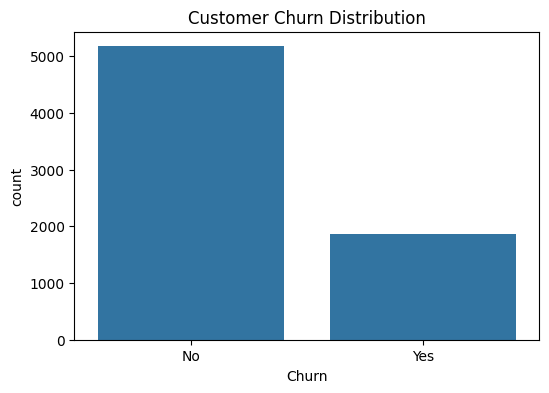

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Churn")

plt.title("Customer Churn Distribution")

plt.show()

### Insight

- Most customers have not churned.
- Approximately 27% of customers have churned.
- This indicates customer churn is a significant business problem.
- Further analysis is needed to identify the reasons behind customer churn.



## 6. Data Cleaning

In this section, we clean the dataset by handling incorrect data types and missing values to improve data quality before analysis.

In [17]:
df["TotalCharges"].dtype

dtype('O')

In [18]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [20]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [21]:
df["TotalCharges"].dtype

dtype('float64')

In [22]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [23]:
df = df.dropna()

In [24]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Data Cleaning Summary

- The `TotalCharges` column was stored as an object data type.
- It contained 11 blank values.
- The column was converted to a numeric data type using `pd.to_numeric()`.
- Blank values were converted into `NaN`.
- Missing records were removed using `dropna()`.
- The dataset is now clean and ready for further analysis.

## 7. Univariate Analysis

Univariate Analysis is used to study one variable at a time. It helps us understand the distribution and characteristics of individual features in the dataset.

### 7.1 Gender Distribution

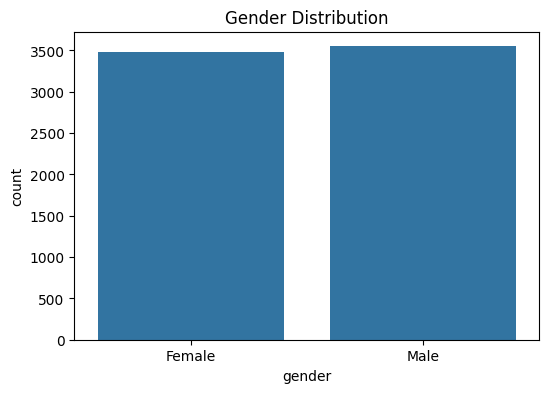

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

### Insight

The dataset contains both male and female customers in almost equal proportions.

This indicates that the dataset is balanced with respect to gender.

### 7.2 Senior Citizen Distribution

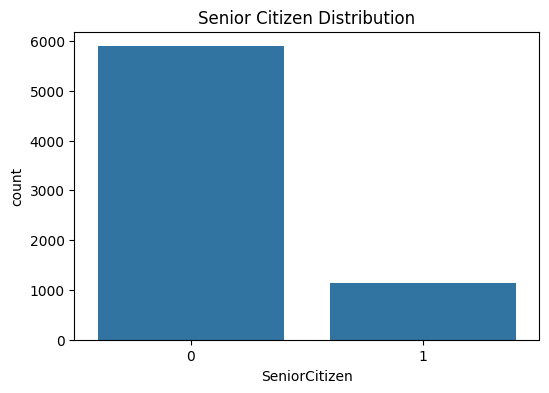

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="SeniorCitizen")
plt.title("Senior Citizen Distribution")
plt.show()

### Insight

Most customers are not senior citizens.

Only a small percentage of customers belong to the senior citizen category.

### 7.3 Partner Distribution

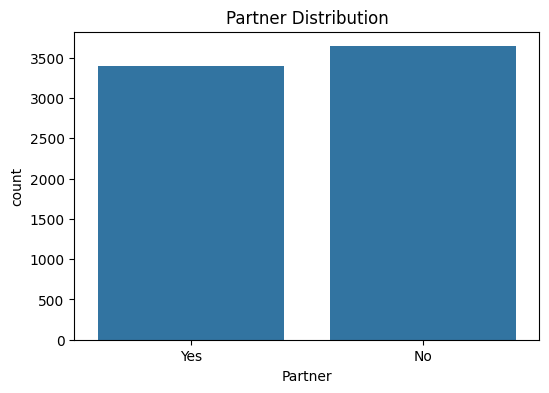

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Partner")
plt.title("Partner Distribution")
plt.show()

### Insight

The dataset contains customers with and without partners.

This feature may influence customer churn and will be analyzed further in the bivariate analysis.

### 7.4 Dependents Distribution

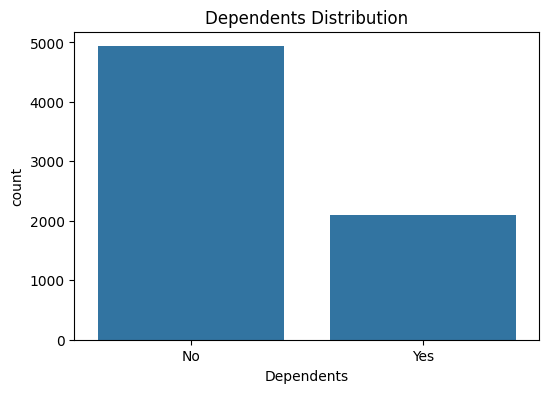

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Dependents")
plt.title("Dependents Distribution")
plt.show()

### Insight

Most customers do not have dependents.

The relationship between dependents and churn will be explored later.

### 7.5 Contract Distribution

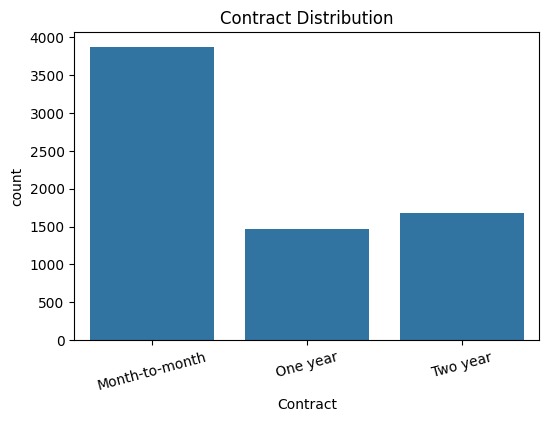

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Contract")
plt.title("Contract Distribution")
plt.xticks(rotation=15)
plt.show()

### 7.6 Internet Service Distribution

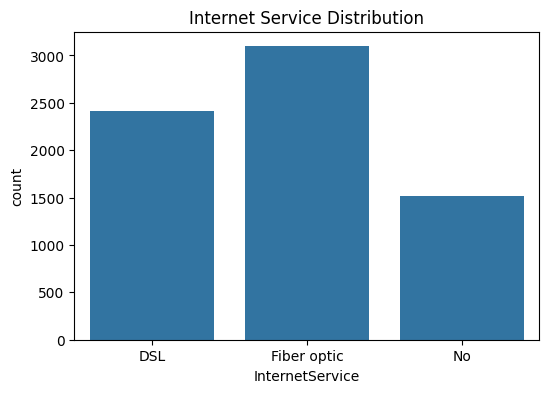

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="InternetService")
plt.title("Internet Service Distribution")
plt.show()

### 7.7 Payment Method Distribution

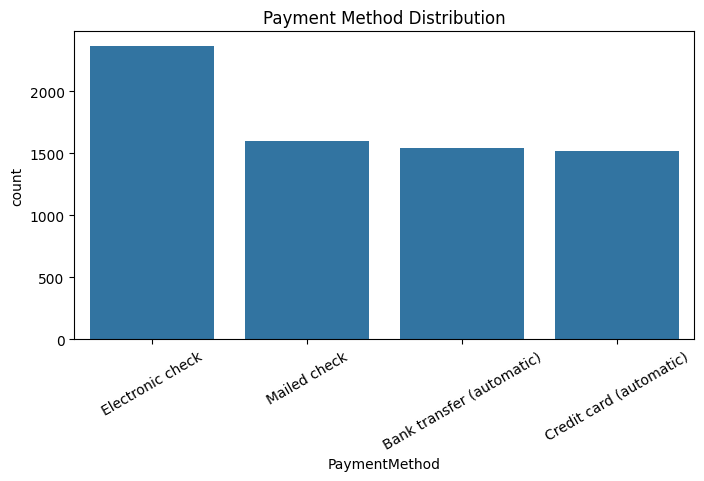

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="PaymentMethod")
plt.title("Payment Method Distribution")
plt.xticks(rotation=30)
plt.show()

### 7.8 Tenure Distribution

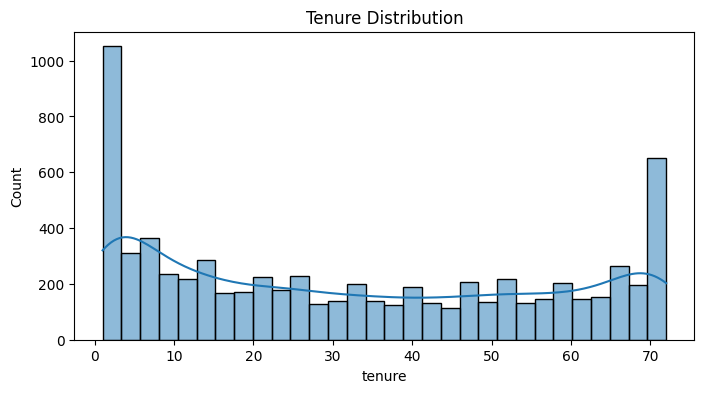

In [32]:
plt.figure(figsize=(8,4))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.show()

### 7.9 Monthly Charges Distribution

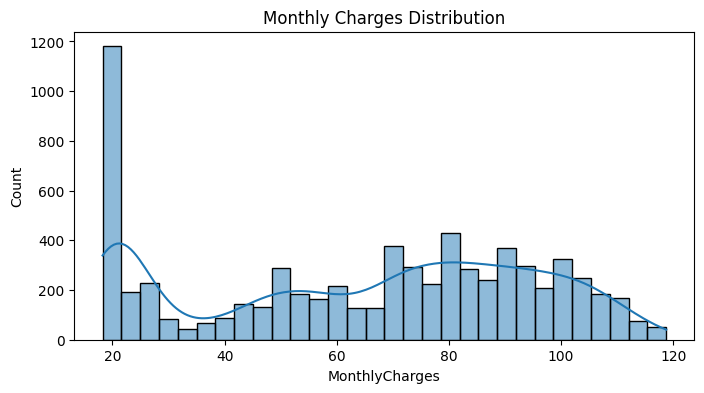

In [33]:
plt.figure(figsize=(8,4))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

### Overall Insights - Univariate Analysis

- The dataset contains a balanced number of male and female customers.
- Most customers are not senior citizens.
- Month-to-month contracts appear more common than long-term contracts.
- Fiber optic and DSL are the primary internet service types.
- Electronic check is one of the most frequently used payment methods.
- Customer tenure and monthly charges show a wide distribution, indicating diverse customer behavior.

## 8. Bivariate Analysis

Bivariate Analysis is used to study the relationship between two variables. In this section, we analyze how different customer attributes are associated with customer churn.

### 8.1 Churn vs Gender

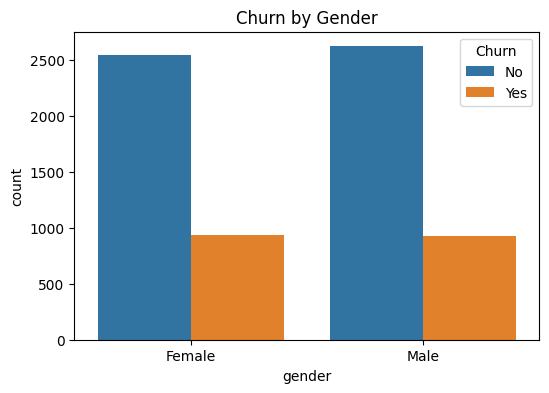

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Churn by Gender")
plt.show()

### 8.2 Churn vs Senior Citizen

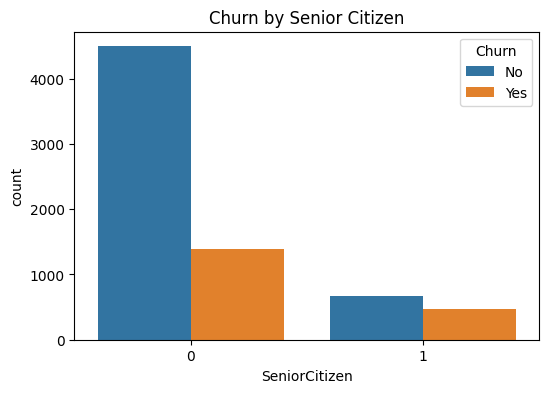

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Churn by Senior Citizen")
plt.show()

### 8.3 Churn vs Contract

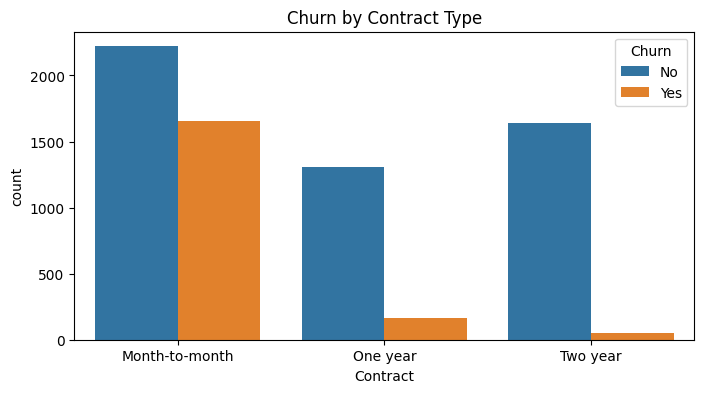

In [36]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

### 8.4 Churn vs Internet Service

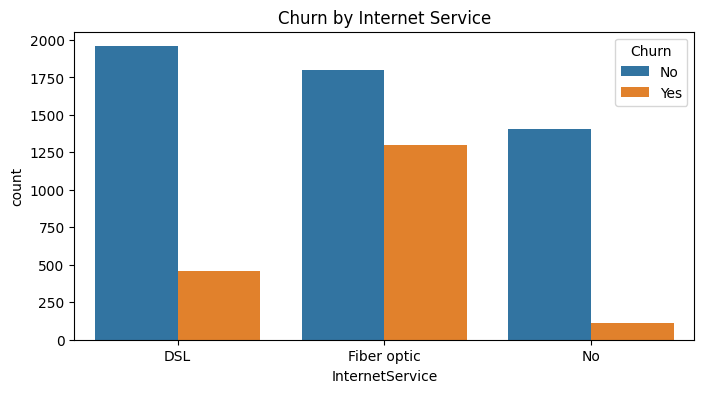

In [37]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

### 8.5 Churn vs Payment Method

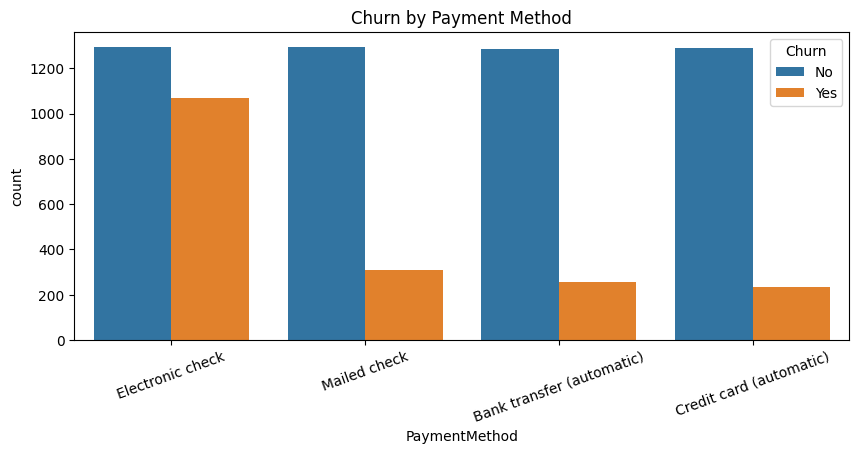

In [38]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xticks(rotation=20)
plt.show()

### 8.6 Monthly Charges vs Churn

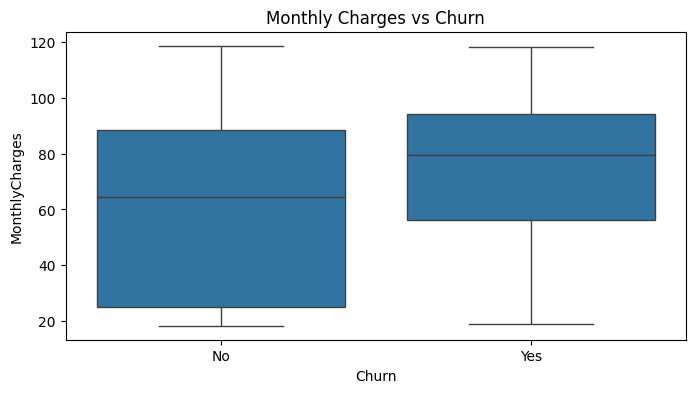

In [39]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

### 8.7 Tenure vs Churn

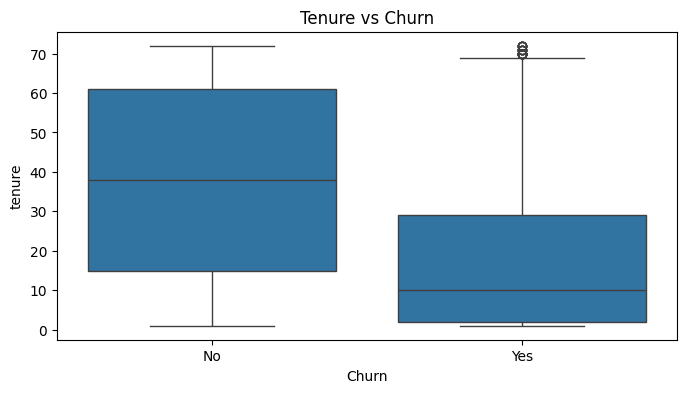

In [40]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

### Overall Insights - Bivariate Analysis

- Customers with month-to-month contracts show higher churn than those with one-year or two-year contracts.
- Customers using Fiber Optic internet appear to churn more frequently.
- Electronic check users show relatively higher churn.
- Customers with shorter tenure are more likely to churn.
- Customers with higher monthly charges tend to churn more often.
- Gender does not appear to have a strong effect on customer churn.

## 9. Multivariate Analysis

Multivariate analysis is used to study the relationship among multiple variables simultaneously to identify complex patterns affecting customer churn.

### 9.1 Correlation Heatmap

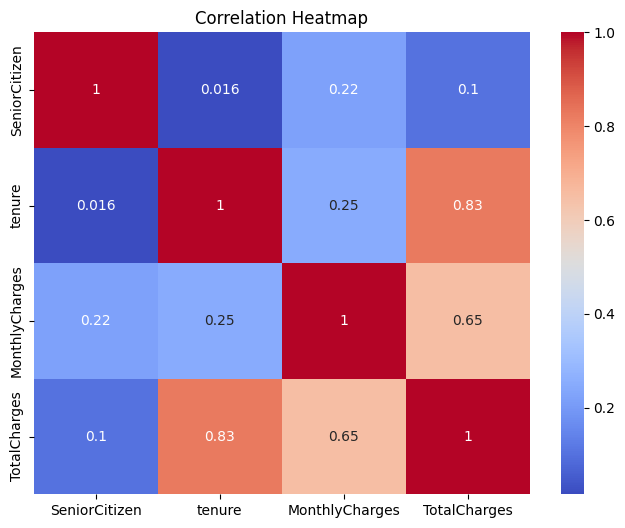

In [41]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### 9.2 Monthly Charges, Contract Type and Churn

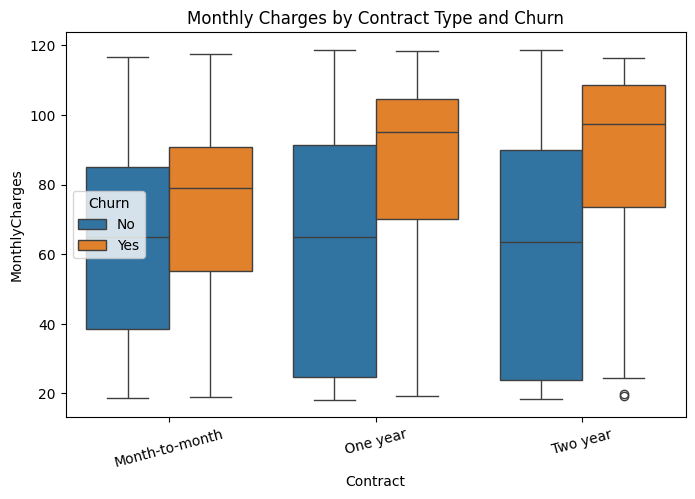

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Contract", y="MonthlyCharges", hue="Churn")

plt.title("Monthly Charges by Contract Type and Churn")

plt.xticks(rotation=15)

plt.show()

### 9.3 Tenure, Contract Type and Churn

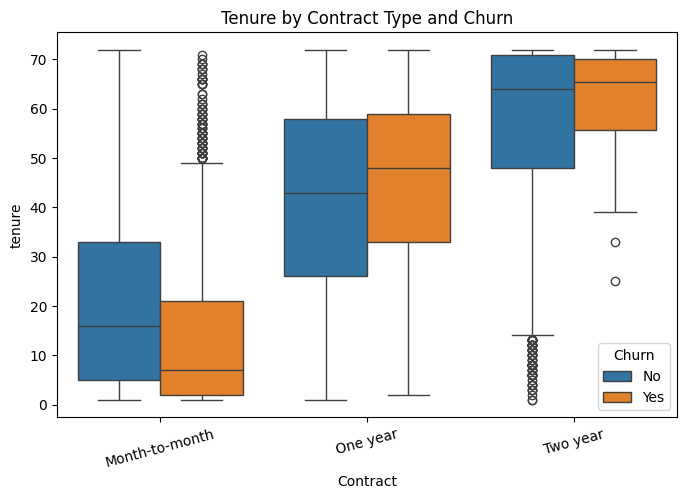

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Contract", y="tenure", hue="Churn")

plt.title("Tenure by Contract Type and Churn")

plt.xticks(rotation=15)

plt.show()

### Overall Insights

- Customers with month-to-month contracts show higher churn rates.
- Customers paying higher monthly charges are more likely to churn.
- Customers with longer tenure generally remain with the company.
- Customer churn is influenced by multiple factors working together rather than a single feature.

## 10. Business Recommendations

Based on the findings from the Exploratory Data Analysis, the following recommendations can help the telecom company reduce customer churn and improve customer satisfaction:

1. Encourage customers to switch from month-to-month contracts to one-year or two-year contracts by offering attractive discounts and loyalty rewards.

2. Improve the quality and reliability of Fiber Optic internet service, as customers using this service appear to leave the company more frequently.

3. Focus on newly joined customers by providing better onboarding support, welcome offers, and regular follow-ups during the first few months.

4. Review pricing strategies for customers with higher monthly charges and introduce flexible or affordable plans to increase customer satisfaction.

5. Encourage customers to use secure and convenient payment methods, such as automatic bank transfer or credit card payments, instead of Electronic Check.

6. Build customer loyalty through reward programs, personalized offers, and proactive customer support to strengthen long-term relationships.

These recommendations can help the company improve customer retention, reduce churn, and enhance overall business performance.

## 11. Conclusion

This project performed an Exploratory Data Analysis (EDA) on the Telco Customer Churn dataset to understand customer behavior and identify the main factors contributing to customer churn.

The analysis revealed that customer churn is influenced by several factors, including contract type, tenure, monthly charges, internet service, and payment method. Customers with month-to-month contracts, shorter tenure, higher monthly charges, and Fiber Optic internet service showed a higher likelihood of leaving the company.

The visualizations and statistical analysis provided valuable insights into customer behavior and highlighted areas where the company can take action to improve customer retention.

Overall, this analysis demonstrates how data-driven decision-making can help businesses better understand their customers, reduce churn, and develop effective retention strategies.